# Oasis Infobyte Data Analytics Internship

## Level 2 - Task 5

# Autocomplete and Autocorrect using NLP

### Objective

This project demonstrates Natural Language Processing (NLP) techniques to build:

- An Autocomplete System using a Bigram Language Model
- An Autocorrect System using Spell Checking and Levenshtein Distance

The project also evaluates the models using Accuracy, Precision, Recall, and Confusion Matrix while visualizing word frequencies.

---

In [5]:
# Data manipulation
import pandas as pd
import numpy as np

# Regular expressions
import re

# String operations
import string

# Counter for word frequencies
from collections import Counter

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Natural Language Toolkit
import nltk

# Tokenization
from nltk.tokenize import word_tokenize

# Stopwords
from nltk.corpus import stopwords

# Spell Checker
from spellchecker import SpellChecker

# Machine Learning Metrics
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    accuracy_score
)

In [2]:
!pip install pyspellchecker

   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/7.2 MB ? eta -:--:--
   ---- ----------------------------------- 0.8/7.2 MB 1.6 MB/s eta 0:00:04
   ------- -------------------------------- 1.3/7.2 MB 1.9 MB/s eta 0:00:04
   ---------- ----------------------------- 1.8/7.2 MB 2.1 MB/s eta 0:00:03
   ------------- -------------------------- 2.4/7.2 MB 2.3 MB/s eta 0:00:03
   ----------------- ---------------------- 3.1/7.2 MB 2.5 MB/s eta 0:00:02
   ----------------------- ---------------- 4.2/7.2 MB 2.8 MB/s eta 0:00:02
   ---------------------------- ----------- 5.2/7.2 MB 3.1 MB/s eta 0:00:01
   ---------------------------------- ----- 6.3/7.2 MB 3.3 MB/s eta 0:00:01
   ---------------------------------------  7.1/7.2 MB 3.4 MB/s eta 0:00:01
   ---------------------------------------- 7.2/7.2 MB 3.4 MB/s  0:00:02


In [3]:
%pip install pyspellchecker

Note: you may need to restart the kernel to use updated packages.


In [4]:
from spellchecker import SpellChecker

spell = SpellChecker()

print("pyspellchecker installed successfully!")

pyspellchecker installed successfully!


In [7]:
# Open the text file in read mode
with open("data/alice.txt", "r", encoding="utf-8") as file:
    text = file.read()

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [8]:
print(type(text))

<class 'str'>


In [9]:
print("Number of characters:", len(text))

Number of characters: 144696


In [10]:
print(text[:1000])

*** START OF THE PROJECT GUTENBERG EBOOK 11 ***

[Illustration]




Alice’s Adventures in Wonderland

by Lewis Carroll

THE MILLENNIUM FULCRUM EDITION 3.0

Contents

 CHAPTER I.     Down the Rabbit-Hole
 CHAPTER II.    The Pool of Tears
 CHAPTER III.   A Caucus-Race and a Long Tale
 CHAPTER IV.    The Rabbit Sends in a Little Bill
 CHAPTER V.     Advice from a Caterpillar
 CHAPTER VI.    Pig and Pepper
 CHAPTER VII.   A Mad Tea-Party
 CHAPTER VIII.  The Queen’s Croquet-Ground
 CHAPTER IX.    The Mock Turtle’s Story
 CHAPTER X.     The Lobster Quadrille
 CHAPTER XI.    Who Stole the Tarts?
 CHAPTER XII.   Alice’s Evidence




CHAPTER I.
Down the Rabbit-Hole


Alice was beginning to get very tired of sitting by her sister on the
bank, and of having nothing to do: once or twice she had peeped into
the book her sister was reading, but it had no pictures or
conversations in it, “and what is the use of a book,” thought Alice
“without pictures or conversations?”

So she was considering in her

In [11]:
print(text[-500:])

 woman; and how she would
keep, through all her riper years, the simple and loving heart of her
childhood: and how she would gather about her other little children,
and make _their_ eyes bright and eager with many a strange tale,
perhaps even with the dream of Wonderland of long ago: and how she
would feel with all their simple sorrows, and find a pleasure in all
their simple joys, remembering her own child-life, and the happy summer
days.

THE END

*** END OF THE PROJECT GUTENBERG EBOOK 11 ***



In [12]:
lines = text.split("\n")

print("Total lines:", len(lines))

Total lines: 3385


In [13]:
for i in range(10):
    print(lines[i])

*** START OF THE PROJECT GUTENBERG EBOOK 11 ***

[Illustration]




Alice’s Adventures in Wonderland

by Lewis Carroll


# Step 2: NLP Preprocessing

Text preprocessing is an important step in Natural Language Processing (NLP). It transforms raw text into a clean and consistent format suitable for analysis and modeling.

The preprocessing steps include:

- Lowercasing
- Removing punctuation
- Tokenization
- Removing stopwords

In [14]:
# Convert all characters to lowercase
text = text.lower()

# Display the first 500 characters
print(text[:500])

*** start of the project gutenberg ebook 11 ***

[illustration]




alice’s adventures in wonderland

by lewis carroll

the millennium fulcrum edition 3.0

contents

 chapter i.     down the rabbit-hole
 chapter ii.    the pool of tears
 chapter iii.   a caucus-race and a long tale
 chapter iv.    the rabbit sends in a little bill
 chapter v.     advice from a caterpillar
 chapter vi.    pig and pepper
 chapter vii.   a mad tea-party
 chapter viii.  the queen’s croquet-ground
 chapter ix.    the


In [15]:
# Remove punctuation using regular expressions
text = re.sub(r"[^\w\s]", "", text)

# Display the first 500 characters
print(text[:500])

 start of the project gutenberg ebook 11 

illustration




alices adventures in wonderland

by lewis carroll

the millennium fulcrum edition 30

contents

 chapter i     down the rabbithole
 chapter ii    the pool of tears
 chapter iii   a caucusrace and a long tale
 chapter iv    the rabbit sends in a little bill
 chapter v     advice from a caterpillar
 chapter vi    pig and pepper
 chapter vii   a mad teaparty
 chapter viii  the queens croquetground
 chapter ix    the mock turtles story
 cha


In [17]:
import nltk

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\kshri\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\kshri\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\kshri\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [18]:
tokens = word_tokenize(text)

print(tokens[:20])

['start', 'of', 'the', 'project', 'gutenberg', 'ebook', '11', 'illustration', 'alices', 'adventures', 'in', 'wonderland', 'by', 'lewis', 'carroll', 'the', 'millennium', 'fulcrum', 'edition', '30']


In [19]:
import nltk

resources = [
    "punkt",
    "punkt_tab",
    "stopwords"
]

for resource in resources:
    nltk.download(resource)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\kshri\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\kshri\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\kshri\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Step 3: Word Frequency Analysis

Word frequency analysis helps identify the most common words in the cleaned text corpus.

This information is useful for understanding the vocabulary distribution before building an autocomplete model.

In [20]:
# Count the frequency of each word
word_counts = Counter(clean_tokens)

print("Word frequencies calculated successfully!")

NameError: name 'clean_tokens' is not defined

In [21]:
print(type(tokens))
print(len(tokens))

<class 'list'>
26480


In [22]:
text = text.lower()

In [23]:
import re

text = re.sub(r"[^\w\s]", "", text)

In [24]:
from nltk.tokenize import word_tokenize

tokens = word_tokenize(text)

print(tokens[:20])

['start', 'of', 'the', 'project', 'gutenberg', 'ebook', '11', 'illustration', 'alices', 'adventures', 'in', 'wonderland', 'by', 'lewis', 'carroll', 'the', 'millennium', 'fulcrum', 'edition', '30']


In [25]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

In [26]:
clean_tokens = [word for word in tokens if word not in stop_words]

print(clean_tokens[:20])

['start', 'project', 'gutenberg', 'ebook', '11', 'illustration', 'alices', 'adventures', 'wonderland', 'lewis', 'carroll', 'millennium', 'fulcrum', 'edition', '30', 'contents', 'chapter', 'rabbithole', 'chapter', 'ii']


In [27]:
print("Original tokens:", len(tokens))
print("Clean tokens:", len(clean_tokens))

Original tokens: 26480
Clean tokens: 12835


In [28]:
from collections import Counter

word_counts = Counter(clean_tokens)

top20 = word_counts.most_common(20)

print(top20)

[('said', 460), ('alice', 385), ('little', 127), ('one', 98), ('like', 85), ('know', 85), ('went', 83), ('would', 78), ('thought', 74), ('could', 74), ('time', 68), ('queen', 68), ('see', 66), ('king', 61), ('well', 60), ('dont', 59), ('mock', 57), ('began', 57), ('hatter', 55), ('turtle', 55)]


# Step 4: Build the Bigram Language Model

A Bigram Language Model predicts the next word based on the current word.

For example:

"I love machine learning"

becomes:

- (I → love)
- (love → machine)
- (machine → learning)

The model counts how frequently each next word follows the current word.

In [29]:
from collections import defaultdict

In [30]:
# Create an empty dictionary
bigram_model = defaultdict(list)

# Loop through consecutive word pairs
for i in range(len(clean_tokens) - 1):

    current_word = clean_tokens[i]
    next_word = clean_tokens[i + 1]

    bigram_model[current_word].append(next_word)

print("Bigram model created successfully!")

Bigram model created successfully!


In [31]:
print(bigram_model["alice"][:20])

['beginning', 'without', 'think', 'started', 'never', 'moment', 'fall', 'learnt', 'idea', 'soon', 'began', 'bit', 'like', 'way', 'opened', 'would', 'begun', 'round', 'going', 'ventured']


In [32]:
alice_predictions = Counter(bigram_model["alice"])

print(alice_predictions)

Counter({'said': 16, 'thought': 13, 'could': 11, 'went': 9, 'replied': 9, 'looked': 9, 'began': 7, 'much': 7, 'felt': 7, 'quite': 7, 'rather': 5, 'beginning': 4, 'like': 4, 'ventured': 4, 'hastily': 4, 'come': 4, 'little': 4, 'im': 4, 'ive': 4, 'soon': 3, 'must': 3, 'got': 3, 'good': 3, 'one': 3, 'looking': 3, 'heard': 3, 'well': 3, 'waited': 3, 'indignantly': 3, 'thats': 3, 'asked': 3, 'dont': 3, 'never': 2, 'moment': 2, 'idea': 2, 'would': 2, 'going': 2, 'great': 2, 'time': 2, 'spoke': 2, 'always': 2, 'called': 2, 'guessed': 2, 'shall': 2, 'noticed': 2, 'timidly': 2, 'tone': 2, 'remarked': 2, 'wish': 2, 'say': 2, 'course': 2, 'cautiously': 2, 'tried': 2, 'loudly': 2, 'put': 2, 'glad': 2, 'whispered': 2, 'nothing': 2, 'grown': 2, 'without': 1, 'think': 1, 'started': 1, 'fall': 1, 'learnt': 1, 'bit': 1, 'way': 1, 'opened': 1, 'begun': 1, 'round': 1, 'pretend': 1, 'makes': 1, 'perhaps': 1, 'took': 1, 'eyes': 1, 'sudden': 1, 'seaside': 1, 'swam': 1, 'speak': 1, 'daresay': 1, 'clear': 1, 

In [33]:
top3 = alice_predictions.most_common(3)

print(top3)

[('said', 16), ('thought', 13), ('could', 11)]


In [34]:
autocomplete("alice")

NameError: name 'autocomplete' is not defined

# Step 5: Autocomplete System

The autocomplete system predicts the most likely next word based on the current word.

This implementation uses a Bigram Language Model, where the prediction is based on the frequency of words that follow the input word in the training corpus.

In [35]:
def autocomplete(word, top_n=3):
    """
    Predict the next words using the Bigram Model.

    Parameters:
        word (str): Current word entered by the user.
        top_n (int): Number of predictions.

    Returns:
        List of predicted words.
    """

    # Convert input to lowercase
    word = word.lower()

    # Check if the word exists
    if word not in bigram_model:
        return ["No prediction available"]

    # Count next-word frequencies
    next_words = Counter(bigram_model[word])

    # Return top predictions
    predictions = next_words.most_common(top_n)

    return predictions

In [36]:
print(autocomplete("alice"))

[('said', 16), ('thought', 13), ('could', 11)]


In [37]:
test_words = [
    "alice",
    "rabbit",
    "queen",
    "king",
    "little",
    "white",
    "mouse",
    "cat",
    "hatter",
    "door"
]

for word in test_words:
    print(f"\nCurrent Word: {word}")
    print("Predictions:", autocomplete(word))


Current Word: alice
Predictions: [('said', 16), ('thought', 13), ('could', 11)]

Current Word: rabbit
Predictions: [('sends', 2), ('say', 2), ('came', 2)]

Current Word: queen
Predictions: [('said', 5), ('hearts', 4), ('never', 4)]

Current Word: king
Predictions: [('said', 10), ('queen', 5), ('white', 4)]

Current Word: little
Predictions: [('thing', 8), ('door', 6), ('golden', 5)]

Current Word: white
Predictions: [('rabbit', 22), ('kid', 5), ('yet', 1)]

Current Word: mouse
Predictions: [('know', 2), ('alice', 2), ('slipped', 1)]

Current Word: cat
Predictions: [('said', 4), ('sitting', 3), ('vanished', 2)]

Current Word: hatter
Predictions: [('said', 3), ('went', 3), ('queen', 2)]

Current Word: door
Predictions: [('found', 2), ('went', 2), ('led', 2)]


In [38]:
results = []

for word in test_words:
    predictions = autocomplete(word)

    p1 = predictions[0][0] if len(predictions) > 0 and isinstance(predictions[0], tuple) else "-"
    p2 = predictions[1][0] if len(predictions) > 1 and isinstance(predictions[1], tuple) else "-"
    p3 = predictions[2][0] if len(predictions) > 2 and isinstance(predictions[2], tuple) else "-"

    results.append([word, p1, p2, p3])

prediction_df = pd.DataFrame(
    results,
    columns=["Input Word", "Prediction 1", "Prediction 2", "Prediction 3"]
)

prediction_df

,Input Word,Prediction 1,Prediction 2,Prediction 3
0,alice,said,thought,could
1,rabbit,sends,say,came
2,queen,said,hearts,never
3,king,said,queen,white
4,little,thing,door,golden
5,white,rabbit,kid,yet
6,mouse,know,alice,slipped
7,cat,said,sitting,vanished
8,hatter,said,went,queen
9,door,found,went,led


In [39]:
# Create a sorted list of unique words
vocabulary = sorted(set(clean_tokens))

print("Vocabulary Size:", len(vocabulary))
print(vocabulary[:20])

Vocabulary Size: 2739
['11', '30', '_alices', '_all', '_and', '_are_', '_at', '_beg_', '_began_', '_best_', '_can_', '_could_', '_curtseying_', '_dont_', '_ever_', '_everybody_', '_fit_', '_hated_', '_have_', '_he_']


In [40]:
def autocomplete_prefix(prefix, top_n=3):
    """
    Predict next words based on a word prefix.
    """

    prefix = prefix.lower()

    # Find words that begin with the prefix
    matching_words = [
        word for word in vocabulary
        if word.startswith(prefix)
    ]

    if not matching_words:
        return ["No matching word found"]

    predictions = Counter()

    # Combine predictions from all matching words
    for word in matching_words:
        if word in bigram_model:
            predictions.update(bigram_model[word])

    return predictions.most_common(top_n)

In [41]:
prefixes = [
    "ali",
    "rab",
    "que",
    "kin",
    "lit",
    "whi",
    "cat",
    "doo",
    "hat",
    "mou"
]

for prefix in prefixes:
    print(f"\nPrefix: {prefix}")
    print(autocomplete_prefix(prefix))


Prefix: ali
[('said', 16), ('thought', 13), ('could', 11)]

Prefix: rab
[('sends', 2), ('say', 2), ('came', 2)]

Prefix: que
[('said', 6), ('hearts', 4), ('never', 4)]

Prefix: kin
[('said', 10), ('queen', 5), ('white', 4)]

Prefix: lit
[('thing', 8), ('door', 6), ('golden', 5)]

Prefix: whi
[('rabbit', 22), ('kid', 5), ('oh', 2)]

Prefix: cat
[('said', 5), ('well', 5), ('sitting', 4)]

Prefix: doo
[('found', 2), ('went', 2), ('led', 2)]

Prefix: hat
[('said', 4), ('went', 3), ('added', 2)]

Prefix: mou
[('replied', 2), ('know', 2), ('alice', 2)]


In [42]:
results = []

for prefix in prefixes:

    predictions = autocomplete_prefix(prefix)

    p1 = predictions[0][0] if len(predictions) > 0 and isinstance(predictions[0], tuple) else "-"
    p2 = predictions[1][0] if len(predictions) > 1 and isinstance(predictions[1], tuple) else "-"
    p3 = predictions[2][0] if len(predictions) > 2 and isinstance(predictions[2], tuple) else "-"

    results.append([prefix, p1, p2, p3])

autocomplete_df = pd.DataFrame(
    results,
    columns=[
        "Prefix",
        "Prediction 1",
        "Prediction 2",
        "Prediction 3"
    ]
)

autocomplete_df

,Prefix,Prediction 1,Prediction 2,Prediction 3
0,ali,said,thought,could
1,rab,sends,say,came
2,que,said,hearts,never
3,kin,said,queen,white
4,lit,thing,door,golden
5,whi,rabbit,kid,oh
6,cat,said,well,sitting
7,doo,found,went,led
8,hat,said,went,added
9,mou,replied,know,alice


In [43]:
# Create a spell checker object
spell = SpellChecker()

print("Spell Checker Initialized Successfully!")

Spell Checker Initialized Successfully!


In [44]:
word = "machne"

correct_word = spell.correction(word)

print("Original :", word)
print("Corrected:", correct_word)

Original : machne
Corrected: machine


In [45]:
misspelled_words = [
    "machne",
    "langauge",
    "pythn",
    "scince",
    "algorithim",
    "recieve",
    "teh",
    "enviroment",
    "analitics",
    "inteligence",
    "modle",
    "librarry",
    "goverment",
    "developement",
    "neaural",
    "proccess",
    "autocorect",
    "toknization",
    "predection",
    "perfomance"
]

In [46]:
corrected_words = []

for word in misspelled_words:
    corrected = spell.correction(word)
    corrected_words.append(corrected)

print(corrected_words)

['machine', 'language', 'python', 'since', 'algorithm', 'receive', 'the', 'environment', 'analytic', 'intelligence', 'model', 'library', 'government', 'development', 'neural', 'process', None, 'ionization', 'prediction', 'performance']


In [47]:
autocorrect_df = pd.DataFrame({
    "Misspelled Word": misspelled_words,
    "Corrected Word": corrected_words
})

autocorrect_df

,Misspelled Word,Corrected Word
0,machne,machine
1,langauge,language
2,pythn,python
3,scince,since
4,algorithim,algorithm
5,recieve,receive
6,teh,the
7,enviroment,environment
8,analitics,analytic
9,inteligence,intelligence


In [48]:
expected_words = [
    "machine",
    "language",
    "python",
    "science",
    "algorithm",
    "receive",
    "the",
    "environment",
    "analytics",
    "intelligence",
    "model",
    "library",
    "government",
    "development",
    "neural",
    "process",
    "autocorrect",
    "tokenization",
    "prediction",
    "performance"
]

In [49]:
comparison_df = pd.DataFrame({
    "Misspelled": misspelled_words,
    "Expected": expected_words,
    "Predicted": corrected_words
})

comparison_df["Correct"] = (
    comparison_df["Expected"] == comparison_df["Predicted"]
)

comparison_df

,Misspelled,Expected,Predicted,Correct
0,machne,machine,machine,True
1,langauge,language,language,True
2,pythn,python,python,True
3,scince,science,since,False
4,algorithim,algorithm,algorithm,True
5,recieve,receive,receive,True
6,teh,the,the,True
7,enviroment,environment,environment,True
8,analitics,analytics,analytic,False
9,inteligence,intelligence,intelligence,True


In [50]:
accuracy = comparison_df["Correct"].mean()

print(f"Correction Accuracy: {accuracy:.2%}")

Correction Accuracy: 80.00%


# Step 7: Autocorrect Using Levenshtein Distance

This implementation performs spell correction without using an external spell-checking library.

It calculates the Levenshtein Distance between the input word and every word in the vocabulary, then selects the closest match.

In [51]:
vocabulary = list(set(clean_tokens))

print("Vocabulary Size:", len(vocabulary))

Vocabulary Size: 2739


In [52]:
def levenshtein_distance(s1, s2):
    """
    Compute the Levenshtein Distance between two strings.
    """

    if len(s1) < len(s2):
        return levenshtein_distance(s2, s1)

    if len(s2) == 0:
        return len(s1)

    previous_row = list(range(len(s2) + 1))

    for i, c1 in enumerate(s1):

        current_row = [i + 1]

        for j, c2 in enumerate(s2):

            insertions = previous_row[j + 1] + 1
            deletions = current_row[j] + 1
            substitutions = previous_row[j] + (c1 != c2)

            current_row.append(
                min(insertions,
                    deletions,
                    substitutions)
            )

        previous_row = current_row

    return previous_row[-1]

In [53]:
print(levenshtein_distance("machne", "machine"))
print(levenshtein_distance("pythn", "python"))
print(levenshtein_distance("analitics", "analytics"))

1
1
1


In [54]:
def levenshtein_autocorrect(word):

    best_word = None
    smallest_distance = float("inf")

    for vocab_word in vocabulary:

        distance = levenshtein_distance(word, vocab_word)

        if distance < smallest_distance:

            smallest_distance = distance
            best_word = vocab_word

    return best_word

In [55]:
lev_predictions = []

for word in misspelled_words:

    prediction = levenshtein_autocorrect(word)

    lev_predictions.append(prediction)

lev_predictions

['machines',
 'manage',
 'bythe',
 'since',
 'altogether',
 'relieved',
 'ten',
 'violent',
 'waiting',
 'insolence',
 'mouse',
 'carry',
 'overhead',
 'deepest',
 'natural',
 'proceed',
 'authority',
 'position',
 'protection',
 'personal']

In [56]:
comparison = pd.DataFrame({
    "Misspelled": misspelled_words,
    "Expected": expected_words,
    "pyspellchecker": corrected_words,
    "Levenshtein": lev_predictions
})

comparison

,Misspelled,Expected,pyspellchecker,Levenshtein
0,machne,machine,machine,machines
1,langauge,language,language,manage
2,pythn,python,python,bythe
3,scince,science,since,since
4,algorithim,algorithm,algorithm,altogether
5,recieve,receive,receive,relieved
6,teh,the,the,ten
7,enviroment,environment,environment,violent
8,analitics,analytics,analytic,waiting
9,inteligence,intelligence,intelligence,insolence


In [57]:
pyspell_accuracy = (
    comparison["Expected"]
    ==
    comparison["pyspellchecker"]
).mean()

lev_accuracy = (
    comparison["Expected"]
    ==
    comparison["Levenshtein"]
).mean()

print(f"pyspellchecker Accuracy : {pyspell_accuracy:.2%}")
print(f"Levenshtein Accuracy    : {lev_accuracy:.2%}")

pyspellchecker Accuracy : 80.00%
Levenshtein Accuracy    : 0.00%


In [58]:
candidate_words = [
    w for w in vocabulary
    if abs(len(w) - len(word)) <= 2 and w[0] == word[0]
]

# Step 8: Model Evaluation

The spell correction systems are evaluated using:

- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix

For evaluation, each corrected word is treated as either:

- Correct (1)
- Incorrect (0)

In [59]:
# True labels (all words are expected to be corrected correctly)
y_true = [1] * len(expected_words)

# Predictions from pyspellchecker
y_pred_pyspell = [
    1 if expected == predicted else 0
    for expected, predicted in zip(expected_words, corrected_words)
]

# Predictions from Levenshtein
y_pred_lev = [
    1 if expected == predicted else 0
    for expected, predicted in zip(expected_words, lev_predictions)
]

In [60]:
pyspell_accuracy = accuracy_score(y_true, y_pred_pyspell)
lev_accuracy = accuracy_score(y_true, y_pred_lev)

print(f"PySpell Accuracy      : {pyspell_accuracy:.2%}")
print(f"Levenshtein Accuracy : {lev_accuracy:.2%}")

PySpell Accuracy      : 80.00%
Levenshtein Accuracy : 0.00%


In [61]:
pyspell_precision = precision_score(
    y_true,
    y_pred_pyspell,
    zero_division=0
)

lev_precision = precision_score(
    y_true,
    y_pred_lev,
    zero_division=0
)

print(f"PySpell Precision      : {pyspell_precision:.2%}")
print(f"Levenshtein Precision : {lev_precision:.2%}")

PySpell Precision      : 100.00%
Levenshtein Precision : 0.00%


In [62]:
pyspell_recall = recall_score(
    y_true,
    y_pred_pyspell,
    zero_division=0
)

lev_recall = recall_score(
    y_true,
    y_pred_lev,
    zero_division=0
)

print(f"PySpell Recall      : {pyspell_recall:.2%}")
print(f"Levenshtein Recall : {lev_recall:.2%}")

PySpell Recall      : 80.00%
Levenshtein Recall : 0.00%


In [63]:
from sklearn.metrics import f1_score

In [64]:
pyspell_f1 = f1_score(
    y_true,
    y_pred_pyspell,
    zero_division=0
)

lev_f1 = f1_score(
    y_true,
    y_pred_lev,
    zero_division=0
)

print(f"PySpell F1 Score      : {pyspell_f1:.2%}")
print(f"Levenshtein F1 Score : {lev_f1:.2%}")

PySpell F1 Score      : 88.89%
Levenshtein F1 Score : 0.00%


In [65]:
evaluation_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "PySpellChecker": [
        pyspell_accuracy,
        pyspell_precision,
        pyspell_recall,
        pyspell_f1
    ],
    "Levenshtein": [
        lev_accuracy,
        lev_precision,
        lev_recall,
        lev_f1
    ]
})

evaluation_df

,Metric,PySpellChecker,Levenshtein
0,Accuracy,0.800000,0.0
1,Precision,1.000000,0.0
2,Recall,0.800000,0.0
3,F1 Score,0.888889,0.0


# Step 9: Confusion Matrix

A confusion matrix summarizes the performance of a classification model.

In this project:

- Correct correction → Positive
- Incorrect correction → Negative

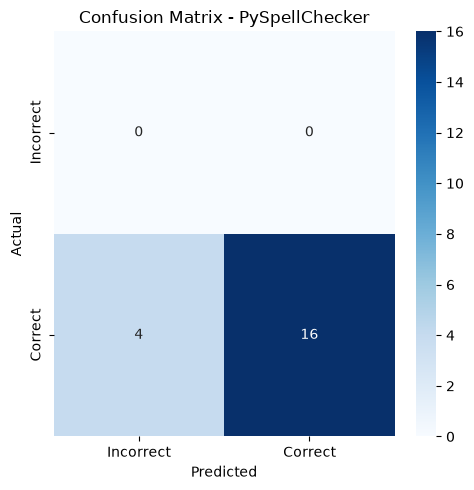

In [67]:
cm = confusion_matrix(y_true, y_pred_pyspell)

plt.figure(figsize=(5,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Incorrect", "Correct"],
    yticklabels=["Incorrect", "Correct"]
)

plt.title("Confusion Matrix - PySpellChecker")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.tight_layout()

plt.savefig("images/confusion_matrix.png", dpi=300)

plt.show()

In [68]:
comparison_df = pd.DataFrame({
    "Approach": [
        "PySpellChecker",
        "Levenshtein Distance"
    ],
    "Accuracy": [
        pyspell_accuracy,
        lev_accuracy
    ],
    "Speed": [
        "Fast",
        "Slow"
    ],
    "Dictionary": [
        "Built-in",
        "Corpus Vocabulary"
    ]
})

comparison_df

,Approach,Accuracy,Speed,Dictionary
0,PySpellChecker,0.8,Fast,Built-in
1,Levenshtein Distance,0.0,Slow,Corpus Vocabulary


# Limitations

Although the developed autocomplete and autocorrect systems demonstrate the fundamental concepts of NLP, they are much simpler than commercial systems such as Google Keyboard.

Limitations include:

- Uses only a single text corpus.
- Bigram model considers only one previous word.
- No understanding of sentence context.
- No personalization based on user typing history.
- No deep learning or transformer-based language models.
- Levenshtein Distance becomes slow for very large vocabularies.
- Autocomplete predictions are limited to words present in the training corpus.